In [127]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Evaluation Metrics
from sklearn.metrics import silhouette_score

In [128]:
# Setup path
BASE_PATH = 'dataset'
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'output_pipeline')
RESULTS_FOLDER = os.path.join(BASE_PATH, 'results')
MODELS_FOLDER = os.path.join(BASE_PATH, 'models')
ARTIFACTS_FOLDER = os.path.join(BASE_PATH, 'artifacts')

In [129]:
# Load dataset
df_cluster = pd.read_parquet(
    os.path.join(
        OUTPUT_FOLDER,
        'stage5_dataset_final.parquet'
    )
)

In [130]:
# Fitur clustering
cluster_features = [
    'luas_panen_ha',
    'PRECTOTCORR_sum_tahun',
    'T2M_mean_tahun',
    'RH2M_mean_tahun',
    'max_consecutive_dry_MK'
]

X_cluster = df_cluster[cluster_features].copy()

In [131]:
# Scaling khusus clustering
scaler_cluster = MinMaxScaler()

X_cluster_scaled = scaler_cluster.fit_transform(
    X_cluster
)

In [132]:
# Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

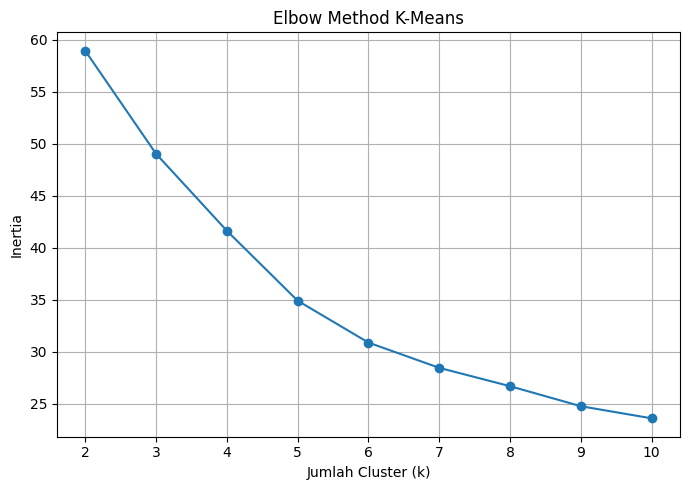

In [133]:
# Plot elbow
plt.figure(figsize=(7,5))
plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.title('Elbow Method K-Means')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

In [134]:
# Check Silhouette Score
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(
        X_cluster_scaled
    )
    score = silhouette_score(
        X_cluster_scaled,
        labels
    )
    print(f"k={k} | silhouette={score:.4f}")

k=2 | silhouette=0.3384
k=3 | silhouette=0.3194
k=4 | silhouette=0.2881
k=5 | silhouette=0.2730
k=6 | silhouette=0.2616
k=7 | silhouette=0.2224
k=8 | silhouette=0.2175
k=9 | silhouette=0.2230
k=10 | silhouette=0.2176


In [135]:
# Final model
best_k = 5
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(
    X_cluster_scaled
)

In [136]:
# Interpretasi cluster
# Cluster 0 = Luas panen sedang, cuaca cukup sejuk, kelembaban tinggi (Wilayah Penyangga).
# Cluster 1 = Luas panen paling kecil, curah hujan & kelembaban paling tinggi, paling sejuk (Wilayah Pegunungan/Hulu).
# Cluster 2 = Luas panen paling besar/masif, curah hujan tinggi, hari kering sangat pendek (Lumbung Pangan Utama).
# Cluster 3 = Luas panen rendah, curah hujan tinggi, suhu paling panas (Wilayah Dataran Rendah/Pesisir).
# Cluster 4 = Luas panen besar nomor dua, curah hujan paling rendah, hari kering paling panjang (Sentra Lahan Kering).

df_cluster['cluster'] = cluster_labels
print(df_cluster['cluster'].value_counts())

cluster
1    173
0    102
3     88
2     46
4     36
Name: count, dtype: int64


In [137]:
# Segmentasi wilayah
wilayah_segmentation = df_cluster[[
    'kabupaten_kota_asli',
    'tahun',
    'cluster'
]]

print(wilayah_segmentation.head(20))

   kabupaten_kota_asli  tahun  cluster
0        Kab. Balangan   2018        0
1        Kab. Balangan   2019        0
2        Kab. Balangan   2020        1
3        Kab. Balangan   2021        1
4        Kab. Balangan   2022        1
5        Kab. Balangan   2023        0
6        Kab. Balangan   2024        0
7        Kab. Balangan   2025        0
8      Kota Balikpapan   2019        0
9      Kota Balikpapan   2020        1
10     Kota Balikpapan   2021        1
11     Kota Balikpapan   2022        1
12     Kota Balikpapan   2023        0
13     Kota Balikpapan   2024        0
14     Kota Balikpapan   2025        0
15         Kab. Banjar   2018        2
16         Kab. Banjar   2019        4
17         Kab. Banjar   2020        2
18         Kab. Banjar   2021        2
19         Kab. Banjar   2022        2


In [138]:
cluster_summary = df_cluster.groupby('cluster')[
    cluster_features
].mean()

print(cluster_summary)

         luas_panen_ha  PRECTOTCORR_sum_tahun  T2M_mean_tahun  \
cluster                                                         
0          9072.690000            2778.370490       26.012981   
1          7604.400405            3439.293988       25.706853   
2         46079.058478            3384.698261       26.557958   
3          8120.878185            3328.038409       27.285584   
4         20269.809167            2470.441111       27.174936   

         RH2M_mean_tahun  max_consecutive_dry_MK  
cluster                                           
0              89.653260               13.980392  
1              91.158269                5.664740  
2              88.353926                8.434783  
3              84.399602                6.920455  
4              83.331228               22.638889  


In [139]:
# Save model k-means
joblib.dump(
    kmeans_model,
    os.path.join(
        MODELS_FOLDER,
        'kmeans_model.joblib'
    )
)

print("KMeans model berhasil disimpan.")

KMeans model berhasil disimpan.


In [140]:
# Save hasil segmentasi
wilayah_segmentation.to_csv(
    os.path.join(
        RESULTS_FOLDER,
        'wilayah_segmentation.csv'
    ),
    index=False
)

print("wilayah_segmentation.csv berhasil disimpan.")

wilayah_segmentation.csv berhasil disimpan.
